# DDoS Detection — Model Comparison

Trains and evaluates multiple models on the synthetic DDoS dataset built in `preprocessing_dataset.ipynb`.
Produces a comparison of all metrics for all models.

## Data split strategy

```
dataset_normal_train.csv  (69 120 rows — all normal, no target)
  ├── unsup_train : 80 % → 55 296 rows   fit unsupervised models
  └── val_normal  : 20 % → 13 824 rows   calibrate anomaly threshold (normal only)

dataset_test_complet.csv  (22 280 rows = 17 280 normal + 5 000 attack)
  ├── val_labeled : 30 % →  6 684 rows   supervised training (5-fold CV) + threshold tuning
  └── test_final  : 70 % → 15 596 rows   FINAL evaluation — touched only once, at the end
```
## Models tested

### Unsupervised (train on normal data only)
1. **Isolation Forest** — ensemble of isolation trees
2. **One-Class SVM** — hyperplane around normal class
3. **Autoencoder** — reconstruction error as anomaly score
4. **Local Outlier Factor** — density-based anomaly

### Supervised (train on labeled data)
5. **Random Forest** — ensemble of decision trees
6. **XGBoost** — gradient boosted trees
7. **MLP Classifier** — multi-layer perceptron
8. **Logistic Regression** — linear baseline

## Important notes on this notebook

### Normalization for unsupervised models
The preprocessing notebook normalized normal and attack data with **separate scalers**,
which destroys the anomaly signal for unsupervised models. This notebook corrects this:
it re-fits a `PowerTransformer(yeo-johnson)` on normal training data only,
then applies the same transformer to the entire test set before any unsupervised model.
PowerTransformer also makes features Gaussian — required for One-Class SVM and LOF.

### Metrics reported for all models
- **Accuracy** — overall correct predictions
- **Precision** — of all predicted attacks, how many are real
- **Recall / TPR** — of all real attacks, how many are caught
- **F1 Score** — harmonic mean of precision and recall
- **FPR** — false positive rate (false alarm rate)
- **AUC-ROC** — area under the ROC curve
- **AUC-PR** — area under the precision-recall curve
- **TPR @ FPR=0.01** — detection rate at 1% false alarm (key metric)
- **TPR @ FPR=0.05** — detection rate at 5% false alarm
- 
### Why F1 and not accuracy?
The test set contains ~22 % attack windows. A model that always predicts *normal* would score **77.6 % accuracy** but **0 % recall** — completely useless for security.  
F1 balances precision and recall, making it the right primary metric for imbalanced binary classification.

### Unsupervised vs Supervised for DDoS detection
Both families are evaluated, but anomaly detection (unsupervised) deserves extra attention because:
- DDoS tactics constantly evolve — future attacks may look nothing like the training examples.
- It fits naturally into **federated learning**: each client trains on its own *normal* traffic; no one needs labelled attack data.
- The 11 features were explicitly designed to deviate from normal during volumetric and protocol-level attacks.

Supervised models typically achieve higher precision on *known* attack types, but may fail silently on novel ones.

In [1]:
# 0. IMPORTS AND GLOBAL CONFIGURATION

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ─── Reproducibility ───────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# ─── Feature names (both files share these column names) ───
FEATURES = [
    'ratio_max_mean_pkts_norm', 'pkts_total_p99_norm', 'bytes_total_p99_norm',
    'proto_udp_share_norm',     'proto_icmp_share_norm', 'syn_ratio_norm',
    'entropy_ip_src_norm',      'pkt_arrivals_avg_p1_norm', 'pkt_size_avg_p1_norm',
    'heure_sin_norm',           'heure_cos_norm'
]

# ─── Primary metric for model selection ────────────────────
PRIMARY_METRIC = 'F1 Score'

# ─── Unsupervised model names (for type labelling later) ───
UNSUP_NAMES = {'Isolation Forest', 'One-Class SVM', 'Autoencoder', 'LOF'}

print('Imports OK')
print(f'Features : {len(FEATURES)}')
print(f'Primary metric : {PRIMARY_METRIC}')

Imports OK
Features : 11
Primary metric : F1 Score


In [2]:
# 1. LOAD RAW FILES


TRAIN_PATH = "/kaggle/input/datasets/eyakhlifi21/ddos-data/dataset_normal_train.csv"
TEST_PATH  = "/kaggle/input/datasets/eyakhlifi21/ddos-data/dataset_test_complet.csv"

df_normal_raw = pd.read_csv(TRAIN_PATH) 
df_test_raw   = pd.read_csv(TEST_PATH)   

# Sanity checks
assert set(FEATURES).issubset(df_normal_raw.columns), 'Feature columns missing in normal train'
assert set(FEATURES).issubset(df_test_raw.columns),   'Feature columns missing in test'
assert 'target' in df_test_raw.columns,               'target column missing in test'
assert 'target' not in df_normal_raw.columns,         'target should NOT be in normal train'

print('=== Normal train ===')
print(f'Shape  : {df_normal_raw.shape}')

print('\n=== Test (normal + attack) ===')
print(f'Shape  : {df_test_raw.shape}')
vc = df_test_raw['target'].value_counts()
print(f'Target : {vc.to_dict()}')
print(f'Attack rate: {df_test_raw["target"].mean():.1%}')

=== Normal train ===
Shape  : (69120, 11)

=== Test (normal + attack) ===
Shape  : (27280, 12)
Target : {0: 17280, 1: 10000}
Attack rate: 36.7%


In [3]:
# 2. PROPER TRAIN / VALIDATION / TEST SPLITS
# test_final is NEVER used for training, threshold-tuning,
# hyperparameter selection, or any decision-making.
# It is touched exactly once: in the final evaluation cell.

# ── 2a. Normal-only split (for unsupervised models) ──────────
X_all_normal = df_normal_raw[FEATURES].values

X_unsup_train, X_val_normal = train_test_split(
    X_all_normal,
    test_size=0.20,
    random_state=RANDOM_STATE
)
# X_unsup_train : fit unsupervised models
# X_val_normal  : compute 99th-pct anomaly threshold (normal only)

# ── 2b. Labeled split (test_complet → val / test) ────────────
X_all  = df_test_raw[FEATURES].values
y_all  = df_test_raw['target'].values

X_val_labeled, X_test_final, y_val_labeled, y_test_final = train_test_split(
    X_all, y_all,
    test_size=0.70,
    stratify=y_all,
    random_state=RANDOM_STATE
)
# X_val_labeled  : supervised training (CV) + threshold tuning
# X_test_final   : LOCKED — final evaluation only

print('=== Split summary ===')
print(f'unsup_train  : {X_unsup_train.shape[0]:>7,} rows  (all normal)')
print(f'val_normal   : {X_val_normal.shape[0]:>7,} rows  (all normal — threshold calibration)')
print(f'val_labeled  : {X_val_labeled.shape[0]:>7,} rows  (attack rate {y_val_labeled.mean():.1%} — supervised train + threshold tuning)')
print(f'test_final   : {X_test_final.shape[0]:>7,} rows  (attack rate {y_test_final.mean():.1%} — LOCKED)')

=== Split summary ===
unsup_train  :  55,296 rows  (all normal)
val_normal   :  13,824 rows  (all normal — threshold calibration)
val_labeled  :   8,184 rows  (attack rate 36.7% — supervised train + threshold tuning)
test_final   :  19,096 rows  (attack rate 36.7% — LOCKED)


In [4]:
# 3. FEATURE NORMALIZATION FOR UNSUPERVISED MODELS

# The preprocessing notebook applied separate RobustScalers to
# normal and attack data, so the saved _norm features are on
# different absolute scales.
#
# Fix: fit a single PowerTransformer on UNSUPERVISED TRAIN only,
# then apply the same transformer to every split.
# PowerTransformer(yeo-johnson) also Gaussianises each feature,
# which is required for One-Class SVM and LOF.
#
# Note: supervised (tree-based) models do NOT need this step
# because trees are invariant to monotone feature transforms.
# For MLP and LR we apply the same transform for consistency.

pt = PowerTransformer(method='yeo-johnson', standardize=True)
pt.fit(X_unsup_train)

# Apply to every split using the SAME fitted transformer
X_unsup_train_pt  = pt.transform(X_unsup_train)
X_val_normal_pt   = pt.transform(X_val_normal)
X_val_labeled_pt  = pt.transform(X_val_labeled)
X_test_final_pt   = pt.transform(X_test_final)

# Quick check: normal training data should look Gaussian after transform
print('PowerTransform verification (normal train — should be ≈ N(0,1)):')
df_check = pd.DataFrame(X_unsup_train_pt, columns=FEATURES)
stats = df_check.describe().loc[['mean', 'std']].round(3)
print(stats.to_string())
print(f'\nAll means ≈ 0  : {(stats.loc["mean"].abs() < 0.05).all()}')
print(f'All stds  ≈ 1  : {((stats.loc["std"] - 1).abs() < 0.10).all()}')

PowerTransform verification (normal train — should be ≈ N(0,1)):
      ratio_max_mean_pkts_norm  pkts_total_p99_norm  bytes_total_p99_norm  proto_udp_share_norm  proto_icmp_share_norm  syn_ratio_norm  entropy_ip_src_norm  pkt_arrivals_avg_p1_norm  pkt_size_avg_p1_norm  heure_sin_norm  heure_cos_norm
mean                       0.0                 -0.0                  -0.0                   0.0                    0.0             0.0                 -0.0                       0.0                  -0.0            -0.0             0.0
std                        1.0                  1.0                   1.0                   1.0                    1.0             1.0                  1.0                       1.0                   1.0             1.0             1.0

All means ≈ 0  : True
All stds  ≈ 1  : True


In [5]:
# 4. METRIC HELPERS

def compute_metrics(y_true, y_pred, y_score):
    """
    Compute all metrics. y_score should be higher for attacks.
    Returns dict with public metrics + private ROC arrays.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    fpr_val   = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)

    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_score)
    tpr_at_001 = float(np.interp(0.01, fpr_arr, tpr_arr))
    tpr_at_005 = float(np.interp(0.05, fpr_arr, tpr_arr))

    return {
        'Accuracy'     : round(accuracy,   4),
        'Precision'    : round(precision,  4),
        'Recall (TPR)' : round(recall,     4),
        'F1 Score'     : round(f1,         4),
        'FPR'          : round(fpr_val,    4),
        'AUC-ROC'      : round(auc_roc,    4),
        'AUC-PR'       : round(auc_pr,     4),
        'TPR@FPR=0.01' : round(tpr_at_001, 4),
        'TPR@FPR=0.05' : round(tpr_at_005, 4),
        # internal — used for plots, not shown in tables
        '_TP': int(tp), '_FP': int(fp), '_TN': int(tn), '_FN': int(fn),
        '_fpr_arr': fpr_arr, '_tpr_arr': tpr_arr,
    }


def tune_threshold_f1(scores_val, y_val, n_grid=300):
    """
    Grid-search the anomaly-score threshold that maximises F1
    on the VALIDATION set.  Returns (best_threshold, best_f1_val).

    Why this is better than the 99th-percentile heuristic:
    - The percentile method is data-agnostic; it ignores the
      actual class distribution in val_labeled.
    - This approach directly optimises the metric we care about.
    """
    lo, hi = np.percentile(scores_val, [0.5, 99.5])  # avoid extreme outliers
    thresholds = np.linspace(lo, hi, n_grid)

    best_f1, best_thresh = -1.0, thresholds[0]
    for t in thresholds:
        preds = (scores_val > t).astype(int)
        if preds.sum() == 0:
            continue
        f = f1_score(y_val, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_thresh = f, t

    return float(best_thresh), float(best_f1)


def pct99_threshold(scores_normal):
    """Classic 99th-percentile threshold on normal-only data."""
    return float(np.percentile(scores_normal, 99))


# Global results store (filled by each model cell)
all_results   = {}   # model_name → metrics dict
all_thresholds = {}  # model_name → {pct99, f1_tuned}

print('Metric helpers ready.')

Metric helpers ready.


---
## Unsupervised Models
Trained on **normal traffic only** (`X_unsup_train_pt`).  
Threshold tuned on **`val_labeled`** to maximise F1.  
Final metrics reported on **`test_final`** (locked).

In [6]:
# 5. MODEL 1 — ISOLATION FOREST (Unsupervised)

print('Training Isolation Forest …')

iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,   # conservative: assume ≤1 % contamination in train
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_unsup_train_pt)

# Higher score → more anomalous (negate score_samples)
scores_iso_val  = -iso.score_samples(X_val_labeled_pt)
scores_iso_test = -iso.score_samples(X_test_final_pt)
scores_iso_norm = -iso.score_samples(X_val_normal_pt)   # for pct99

# ── Threshold comparison ────────────────────────────────────
t_pct99,   _          = pct99_threshold(scores_iso_norm), None
t_f1_iso, val_f1_iso  = tune_threshold_f1(scores_iso_val, y_val_labeled)

print(f'  Threshold pct99   : {t_pct99:.4f}')
print(f'  Threshold F1-tuned: {t_f1_iso:.4f}  (val F1={val_f1_iso:.4f})')

# Use F1-tuned threshold for final evaluation
iso_pred_test = (scores_iso_test > t_f1_iso).astype(int)
results_iso   = compute_metrics(y_test_final, iso_pred_test, scores_iso_test)

all_results['Isolation Forest']    = results_iso
all_thresholds['Isolation Forest'] = {'pct99': t_pct99, 'f1_tuned': t_f1_iso}

print(f"  ── Test metrics (threshold=F1-tuned) ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_iso[k]}')

Training Isolation Forest …
  Threshold pct99   : 0.5922
  Threshold F1-tuned: 0.6157  (val F1=0.9843)
  ── Test metrics (threshold=F1-tuned) ──
  F1 Score          : 0.9835
  AUC-ROC           : 0.9985
  Recall (TPR)      : 0.9727
  FPR               : 0.0031
  TPR@FPR=0.01      : 0.9797


In [7]:
# 6. MODEL 2 — ONE-CLASS SVM (Unsupervised)
#    Requires Gaussian features — PowerTransformer handles this.
#    Subsampled to 10 k for tractability (OC-SVM is O(n²)).

print('Training One-Class SVM  (subsampled to 10 k) …')

n_sub = min(10_000, len(X_unsup_train_pt))
idx   = np.random.choice(len(X_unsup_train_pt), n_sub, replace=False)

ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(X_unsup_train_pt[idx])

# Higher → more anomalous
scores_ocsvm_val  = -ocsvm.decision_function(X_val_labeled_pt)
scores_ocsvm_test = -ocsvm.decision_function(X_test_final_pt)
scores_ocsvm_norm = -ocsvm.decision_function(X_val_normal_pt)

t_pct99_oc          = pct99_threshold(scores_ocsvm_norm)
t_f1_oc, val_f1_oc  = tune_threshold_f1(scores_ocsvm_val, y_val_labeled)

print(f'  Threshold pct99   : {t_pct99_oc:.4f}')
print(f'  Threshold F1-tuned: {t_f1_oc:.4f}  (val F1={val_f1_oc:.4f})')

ocsvm_pred_test = (scores_ocsvm_test > t_f1_oc).astype(int)
results_ocsvm   = compute_metrics(y_test_final, ocsvm_pred_test, scores_ocsvm_test)

all_results['One-Class SVM']    = results_ocsvm
all_thresholds['One-Class SVM'] = {'pct99': t_pct99_oc, 'f1_tuned': t_f1_oc}

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_ocsvm[k]}')

Training One-Class SVM  (subsampled to 10 k) …
  Threshold pct99   : 7.4664
  Threshold F1-tuned: 15.8886  (val F1=1.0000)
  ── Test metrics ──
  F1 Score          : 0.9996
  AUC-ROC           : 1.0
  Recall (TPR)      : 1.0
  FPR               : 0.0004
  TPR@FPR=0.01      : 1.0


In [8]:
# 7. MODEL 3 — AUTOENCODER (Unsupervised)
#
# Improvements over baseline:
#  • Weight decay (L2) to reduce overfitting
#  • ReduceLROnPlateau scheduler to escape plateaus
#  • Early stopping on the NORMAL validation set (not test set)
#  • Threshold tuned on val_labeled for F1
#  • Learning curve saved for inspection

print('Training Autoencoder …')

INPUT_DIM = X_unsup_train_pt.shape[1]   


class Autoencoder(nn.Module):
    """Symmetric encoder-decoder with Tanh activations.
    Architecture follows Kitsune (Mirsky et al., NDSS 2018).
    """
    def __init__(self, input_dim, hidden_dim=32, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 16),        nn.Tanh(),
            nn.Linear(16, latent_dim),         nn.Tanh(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),         nn.Tanh(),
            nn.Linear(16, hidden_dim),         nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# ── Data loaders ───────────────────────────────────────────
# Use X_val_normal_pt for early stopping — normal only, no leakage
T_train = torch.FloatTensor(X_unsup_train_pt)
T_vnorm = torch.FloatTensor(X_val_normal_pt)
T_vlbl  = torch.FloatTensor(X_val_labeled_pt)
T_test  = torch.FloatTensor(X_test_final_pt)

loader_train = DataLoader(
    TensorDataset(T_train, T_train),
    batch_size=512, shuffle=True, drop_last=False
)

ae        = Autoencoder(input_dim=INPUT_DIM, hidden_dim=32, latent_dim=6)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
# ReduceLROnPlateau: halve LR if val loss stagnates for 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)
criterion = nn.MSELoss()

MAX_EPOCHS    = 150
PATIENCE_ES   = 10     # early-stopping patience
best_val_loss = float('inf')
patience_ctr  = 0
best_state    = None
train_losses, val_losses = [], []

for epoch in range(MAX_EPOCHS):
    ae.train()
    epoch_loss = 0.0
    for xb, yb in loader_train:
        optimizer.zero_grad()
        loss = criterion(ae(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(loader_train)

    ae.eval()
    with torch.no_grad():
        val_loss = criterion(ae(T_vnorm), T_vnorm).item()

    scheduler.step(val_loss)
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        best_state    = {k: v.clone() for k, v in ae.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE_ES:
            print(f'  Early stop at epoch {epoch+1} | best val_loss={best_val_loss:.6f}')
            break

    if (epoch + 1) % 20 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{MAX_EPOCHS} | '
              f'train={epoch_loss:.6f} | val={val_loss:.6f} | lr={lr_now:.2e}')

ae.load_state_dict(best_state)
ae.eval()

# ── Compute anomaly scores (MSE per sample) ─────────────────
with torch.no_grad():
    ae_scores_norm = torch.mean((T_vnorm - ae(T_vnorm))**2, dim=1).numpy()
    ae_scores_val  = torch.mean((T_vlbl  - ae(T_vlbl))**2,  dim=1).numpy()
    ae_scores_test = torch.mean((T_test  - ae(T_test))**2,  dim=1).numpy()

# ── Threshold comparison ────────────────────────────────────
t_pct99_ae          = pct99_threshold(ae_scores_norm)
t_f1_ae, val_f1_ae  = tune_threshold_f1(ae_scores_val, y_val_labeled)

print(f'\n  Threshold pct99   : {t_pct99_ae:.6f}')
print(f'  Threshold F1-tuned: {t_f1_ae:.6f}  (val F1={val_f1_ae:.4f})')

ae_pred_test = (ae_scores_test > t_f1_ae).astype(int)
results_ae   = compute_metrics(y_test_final, ae_pred_test, ae_scores_test)

all_results['Autoencoder']    = results_ae
all_thresholds['Autoencoder'] = {
    'pct99': t_pct99_ae, 'f1_tuned': t_f1_ae,
    'train_losses': train_losses, 'val_losses': val_losses,
}

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_ae[k]}')

Training Autoencoder …
  Epoch  20/150 | train=0.157105 | val=0.154126 | lr=1.00e-03
  Epoch  40/150 | train=0.121247 | val=0.119626 | lr=1.00e-03
  Epoch  60/150 | train=0.111678 | val=0.111638 | lr=1.00e-03
  Epoch  80/150 | train=0.109485 | val=0.109446 | lr=1.00e-03
  Epoch 100/150 | train=0.108137 | val=0.108340 | lr=1.00e-03
  Epoch 120/150 | train=0.107031 | val=0.107024 | lr=1.00e-03
  Epoch 140/150 | train=0.106297 | val=0.106137 | lr=1.00e-03

  Threshold pct99   : 0.531007
  Threshold F1-tuned: 0.005849  (val F1=0.5385)
  ── Test metrics ──
  F1 Score          : 0.5377
  AUC-ROC           : 1.0
  Recall (TPR)      : 1.0
  FPR               : 0.9952
  TPR@FPR=0.01      : 1.0


In [9]:
# 8. MODEL 4 — LOCAL OUTLIER FACTOR (Unsupervised)
#    Subsampled to 15 k for speed.

print('Training LOF (subsampled to 15 k) …')

n_lof = min(15_000, len(X_unsup_train_pt))
idx_l = np.random.choice(len(X_unsup_train_pt), n_lof, replace=False)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=True,      # allows predict() on unseen data
    n_jobs=-1,
)
lof.fit(X_unsup_train_pt[idx_l])

scores_lof_val  = -lof.decision_function(X_val_labeled_pt)
scores_lof_test = -lof.decision_function(X_test_final_pt)
scores_lof_norm = -lof.decision_function(X_val_normal_pt)

t_pct99_lof          = pct99_threshold(scores_lof_norm)
t_f1_lof, val_f1_lof = tune_threshold_f1(scores_lof_val, y_val_labeled)

print(f'  Threshold pct99   : {t_pct99_lof:.4f}')
print(f'  Threshold F1-tuned: {t_f1_lof:.4f}  (val F1={val_f1_lof:.4f})')

lof_pred_test = (scores_lof_test > t_f1_lof).astype(int)
results_lof   = compute_metrics(y_test_final, lof_pred_test, scores_lof_test)

all_results['LOF']    = results_lof
all_thresholds['LOF'] = {'pct99': t_pct99_lof, 'f1_tuned': t_f1_lof}

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_lof[k]}')

Training LOF (subsampled to 15 k) …
  Threshold pct99   : -0.0162
  Threshold F1-tuned: 16.9259  (val F1=0.9773)
  ── Test metrics ──
  F1 Score          : 0.9759
  AUC-ROC           : 1.0
  Recall (TPR)      : 0.953
  FPR               : 0.0
  TPR@FPR=0.01      : 1.0


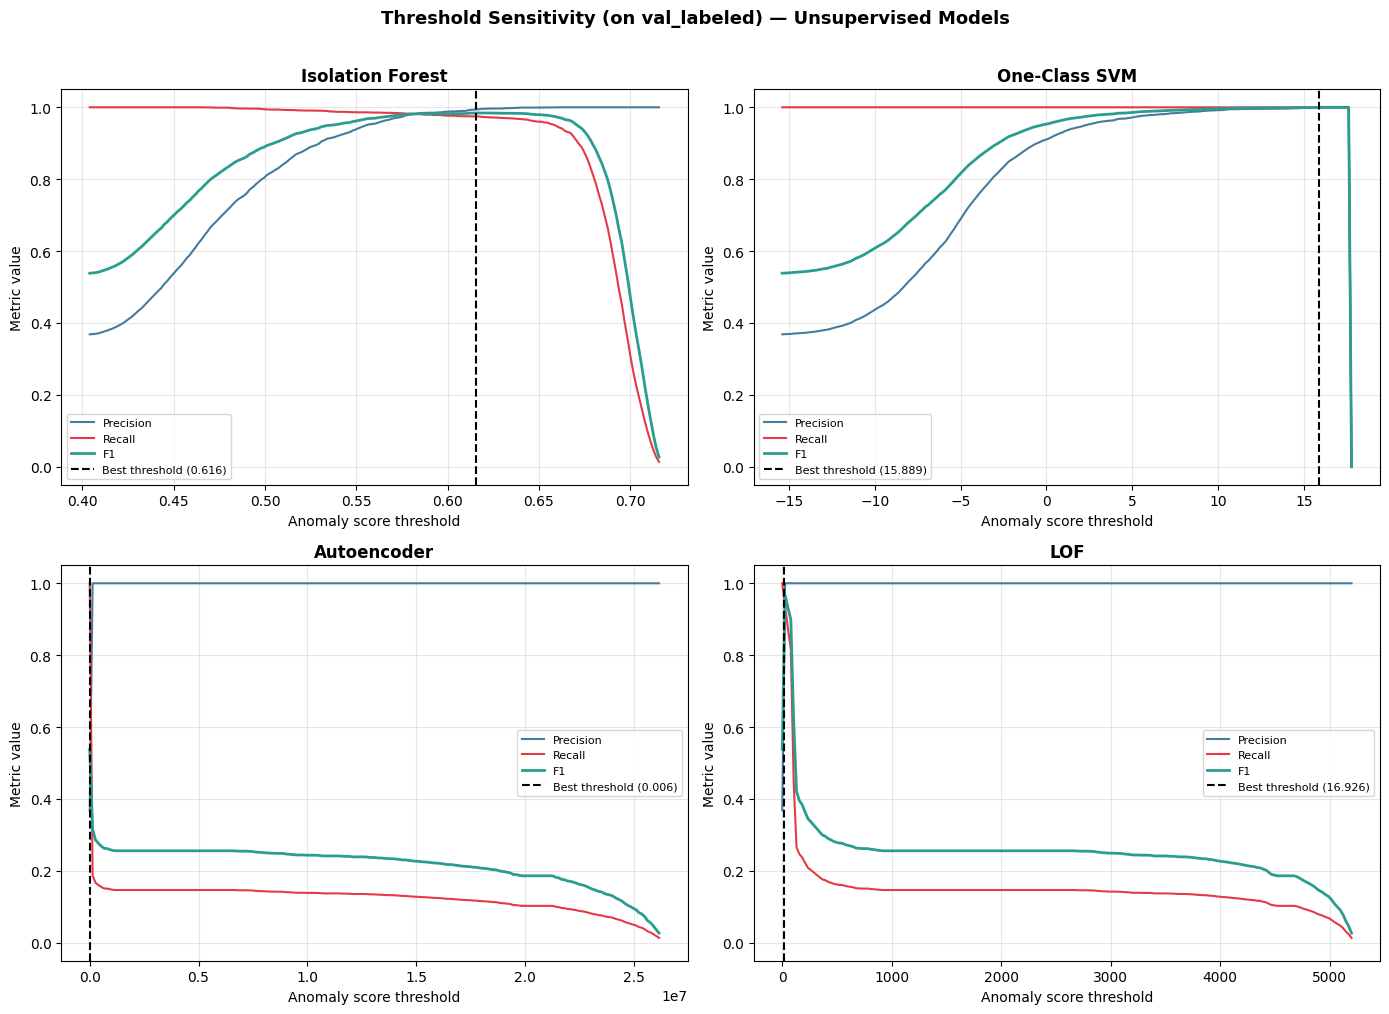

Saved: threshold_sensitivity.png


In [10]:
# 9. THRESHOLD SENSITIVITY ANALYSIS (Unsupervised models)
#
# Shows how Precision, Recall, and F1 change as the threshold
# varies on val_labeled.  Helps verify that the F1-tuned
# threshold is at a good operating point.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

unsup_score_data = {
    'Isolation Forest': scores_iso_val,
    'One-Class SVM'   : scores_ocsvm_val,
    'Autoencoder'     : ae_scores_val,
    'LOF'             : scores_lof_val,
}
unsup_best_t = {
    'Isolation Forest': t_f1_iso,
    'One-Class SVM'   : t_f1_oc,
    'Autoencoder'     : t_f1_ae,
    'LOF'             : t_f1_lof,
}

for ax, (name, scores) in zip(axes.flatten(), unsup_score_data.items()):
    lo, hi = np.percentile(scores, [0.5, 99.5])
    thresholds = np.linspace(lo, hi, 200)
    precs, recs, f1s = [], [], []
    for t in thresholds:
        preds = (scores > t).astype(int)
        if preds.sum() == 0:
            precs.append(0); recs.append(0); f1s.append(0)
            continue
        precs.append(precision_score(y_val_labeled, preds, zero_division=0))
        recs.append(recall_score(y_val_labeled, preds, zero_division=0))
        f1s.append(f1_score(y_val_labeled, preds, zero_division=0))

    best_t = unsup_best_t[name]
    ax.plot(thresholds, precs, label='Precision', color='#457B9D', lw=1.5)
    ax.plot(thresholds, recs,  label='Recall',    color='#E63946', lw=1.5)
    ax.plot(thresholds, f1s,   label='F1',        color='#2A9D8F', lw=2.0)
    ax.axvline(best_t, color='black', linestyle='--', lw=1.5,
               label=f'Best threshold ({best_t:.3f})')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Anomaly score threshold')
    ax.set_ylabel('Metric value')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Threshold Sensitivity (on val_labeled) — Unsupervised Models',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_sensitivity.png')

---
## Supervised Models
Trained on **`val_labeled`** using **5-fold stratified cross-validation**.  
Best hyperparameters selected on CV F1. Model re-trained on full `val_labeled`.  
Final metrics reported on **`test_final`** (same locked set as unsupervised).

In [11]:
# 10. CROSS-VALIDATION HELPER (Supervised)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CV_SCORING = {
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
    'precision': 'precision',
    'recall'   : 'recall',
}

def run_cv(model, X, y, label):
    """Run CV, print summary, return cv_results dict."""
    cv_res = cross_validate(model, X, y, cv=CV, scoring=CV_SCORING,
                            return_train_score=False, n_jobs=-1)
    print(f'  CV results ({label}):')
    for metric in ['f1', 'roc_auc', 'precision', 'recall']:
        arr = cv_res[f'test_{metric}']
        print(f'    {metric:<12}: {arr.mean():.4f} ± {arr.std():.4f}')
    return cv_res

print('CV helper ready (5-fold stratified, primary metric = F1).')

CV helper ready (5-fold stratified, primary metric = F1).


In [12]:
# 11. MODEL 5 — RANDOM FOREST (Supervised)
#
# class_weight='balanced' handles the ~22 % attack rate.
# CV checks for overfitting (train-CV gap).

print('Training Random Forest …')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,      # slight regularisation
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Cross-validation on val_labeled
_ = run_cv(rf, X_val_labeled, y_val_labeled, 'Random Forest')

# Re-train on full val_labeled, evaluate on locked test_final
rf.fit(X_val_labeled, y_val_labeled)
rf_pred   = rf.predict(X_test_final)
rf_scores = rf.predict_proba(X_test_final)[:, 1]

results_rf = compute_metrics(y_test_final, rf_pred, rf_scores)
all_results['Random Forest'] = results_rf

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_rf[k]}')

# Feature importances
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\n  Top 5 features (Gini):')
print(imp.head(5).round(4).to_string())

Training Random Forest …
  CV results (Random Forest):
    f1          : 1.0000 ± 0.0000
    roc_auc     : 1.0000 ± 0.0000
    precision   : 1.0000 ± 0.0000
    recall      : 1.0000 ± 0.0000
  ── Test metrics ──
  F1 Score          : 1.0
  AUC-ROC           : 1.0
  Recall (TPR)      : 1.0
  FPR               : 0.0
  TPR@FPR=0.01      : 1.0

  Top 5 features (Gini):
pkt_arrivals_avg_p1_norm    0.2597
pkts_total_p99_norm         0.2514
proto_udp_share_norm        0.1644
proto_icmp_share_norm       0.1252
pkt_size_avg_p1_norm        0.0957


In [13]:
# 12. MODEL 6 — XGBOOST (Supervised)
#
# Early stopping: we hold out 15 % of val_labeled as an
# XGBoost eval set, then re-train on full val_labeled for
# the final model.

print('Training XGBoost …')

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    print('  XGBoost not installed — skipping.  pip install xgboost')
    xgb_available = False

if xgb_available:
    # ── Early stopping: hold out 15 % of val_labeled for eval ─
    X_xgb_tr, X_xgb_es, y_xgb_tr, y_xgb_es = train_test_split(
        X_val_labeled, y_val_labeled,
        test_size=0.15, stratify=y_val_labeled, random_state=RANDOM_STATE
    )

    neg_count = (y_xgb_tr == 0).sum()
    pos_count = (y_xgb_tr == 1).sum()

    xgb_es = XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=neg_count / pos_count,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=30,
        verbosity=0,
        n_jobs=-1,
    )
    xgb_es.fit(
        X_xgb_tr, y_xgb_tr,
        eval_set=[(X_xgb_es, y_xgb_es)],
        verbose=False,
    )
    best_n = xgb_es.best_iteration
    print(f'  Early stopping: best n_estimators = {best_n}')

    # ── CV with the determined n_estimators ───────────────────
    xgb_cv = XGBClassifier(
        n_estimators=best_n,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=neg_count / pos_count,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1,
    )
    _ = run_cv(xgb_cv, X_val_labeled, y_val_labeled, 'XGBoost')

    # ── Re-train on full val_labeled, evaluate on test_final ──
    xgb_cv.fit(X_val_labeled, y_val_labeled, verbose=False)
    xgb_pred   = xgb_cv.predict(X_test_final)
    xgb_scores = xgb_cv.predict_proba(X_test_final)[:, 1]

    results_xgb = compute_metrics(y_test_final, xgb_pred, xgb_scores)
    all_results['XGBoost'] = results_xgb

    print(f"  ── Test metrics ──")
    for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
        print(f'  {k:<18}: {results_xgb[k]}')

Training XGBoost …
  Early stopping: best n_estimators = 473
  CV results (XGBoost):
    f1          : 0.9992 ± 0.0009
    roc_auc     : 1.0000 ± 0.0000
    precision   : 0.9993 ± 0.0008
    recall      : 0.9990 ± 0.0020
  ── Test metrics ──
  F1 Score          : 0.9994
  AUC-ROC           : 1.0
  Recall (TPR)      : 1.0
  FPR               : 0.0007
  TPR@FPR=0.01      : 1.0


In [14]:
# ============================================================
# 13. MODEL 7 — MLP CLASSIFIER (Supervised)
#
# sklearn's MLPClassifier already supports early_stopping=True.
# We add L2 regularisation (alpha) to prevent overfitting.
# ============================================================
print('Training MLP …')

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=1e-4,                 # L2 weight decay
    batch_size=256,
    learning_rate='adaptive',   # halves LR when loss stops improving
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,        # uses 10 % of training data as validation
    validation_fraction=0.10,
    n_iter_no_change=15,        # patience
    tol=1e-5,
    random_state=RANDOM_STATE,
)

_ = run_cv(mlp, X_val_labeled_pt, y_val_labeled, 'MLP (PT features)')

# Re-train on full val_labeled_pt
mlp.fit(X_val_labeled_pt, y_val_labeled)
print(f'  Converged after {mlp.n_iter_} iterations')

mlp_pred   = mlp.predict(X_test_final_pt)
mlp_scores = mlp.predict_proba(X_test_final_pt)[:, 1]

results_mlp = compute_metrics(y_test_final, mlp_pred, mlp_scores)
all_results['MLP'] = results_mlp

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_mlp[k]}')

Training MLP …
  CV results (MLP (PT features)):
    f1          : 0.9957 ± 0.0058
    roc_auc     : 0.9993 ± 0.0013
    precision   : 0.9925 ± 0.0117
    recall      : 0.9990 ± 0.0020
  Converged after 21 iterations
  ── Test metrics ──
  F1 Score          : 0.9977
  AUC-ROC           : 0.9996
  Recall (TPR)      : 0.9971
  FPR               : 0.001
  TPR@FPR=0.01      : 0.9983


In [15]:
# 14. MODEL 8 — LOGISTIC REGRESSION (Supervised baseline)

print('Training Logistic Regression …')

lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=500,
    solver='lbfgs',
    random_state=RANDOM_STATE,
)

_ = run_cv(lr, X_val_labeled_pt, y_val_labeled, 'Logistic Regression')

lr.fit(X_val_labeled_pt, y_val_labeled)
lr_pred   = lr.predict(X_test_final_pt)
lr_scores = lr.predict_proba(X_test_final_pt)[:, 1]

results_lr = compute_metrics(y_test_final, lr_pred, lr_scores)
all_results['Logistic Regression'] = results_lr

print(f"  ── Test metrics ──")
for k in ['F1 Score', 'AUC-ROC', 'Recall (TPR)', 'FPR', 'TPR@FPR=0.01']:
    print(f'  {k:<18}: {results_lr[k]}')

Training Logistic Regression …
  CV results (Logistic Regression):
    f1          : 1.0000 ± 0.0000
    roc_auc     : 1.0000 ± 0.0000
    precision   : 1.0000 ± 0.0000
    recall      : 1.0000 ± 0.0000
  ── Test metrics ──
  F1 Score          : 1.0
  AUC-ROC           : 1.0
  Recall (TPR)      : 1.0
  FPR               : 0.0
  TPR@FPR=0.01      : 1.0


---
## Final Evaluation
> **This is the only cell that uses `test_final`** (for all models simultaneously).  
> No model saw this data during training, threshold calibration, or model selection.

In [16]:
# 15. FINAL COMPARISON TABLE — ALL MODELS ON test_final

METRIC_COLS = [
    'Accuracy', 'Precision', 'Recall (TPR)', 'F1 Score',
    'FPR', 'AUC-ROC', 'AUC-PR', 'TPR@FPR=0.01', 'TPR@FPR=0.05'
]

rows = []
for name, res in all_results.items():
    row = {'Model': name, 'Type': 'Unsup.' if name in UNSUP_NAMES else 'Sup.'}
    for col in METRIC_COLS:
        row[col] = res.get(col, float('nan'))
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index('Model')

# ── Highlight best value per metric column ─────────────────
pd.set_option('display.float_format', '{:.4f}'.format)

print('='*120)
print('FINAL MODEL COMPARISON  —  test_final  (all models evaluated on the same held-out set)')
print('='*120)
print(df_cmp.to_string())

print('\nNOTE  Unsupervised = trained on normal data only; threshold tuned on val_labeled.')
print('      Supervised   = trained on val_labeled (5-fold CV); no overlap with test_final.')

df_cmp.to_csv('model_comparison_results.csv')
print('\nSaved: model_comparison_results.csv')

FINAL MODEL COMPARISON  —  test_final  (all models evaluated on the same held-out set)
                       Type  Accuracy  Precision  Recall (TPR)  F1 Score    FPR  AUC-ROC  AUC-PR  TPR@FPR=0.01  TPR@FPR=0.05
Model                                                                                                                       
Isolation Forest     Unsup.    0.9881     0.9946        0.9727    0.9835 0.0031   0.9985  0.9978        0.9797        0.9900
One-Class SVM        Unsup.    0.9997     0.9993        1.0000    0.9996 0.0004   1.0000  1.0000        1.0000        1.0000
Autoencoder          Unsup.    0.3696     0.3677        1.0000    0.5377 0.9952   1.0000  1.0000        1.0000        1.0000
LOF                  Unsup.    0.9828     1.0000        0.9530    0.9759 0.0000   1.0000  1.0000        1.0000        1.0000
Random Forest          Sup.    1.0000     1.0000        1.0000    1.0000 0.0000   1.0000  1.0000        1.0000        1.0000
XGBoost                Sup.    0.9996 

In [17]:
# 16. MODEL RANKING BY F1  (primary metric)

rank = df_cmp[['Type', 'F1 Score', 'AUC-ROC', 'Recall (TPR)',
               'FPR', 'TPR@FPR=0.01']].sort_values('F1 Score', ascending=False)

print('=== MODEL RANKING (F1 Score — primary metric) ===')
print(rank.to_string())

winner = rank.index[0]
winner_f1  = rank.loc[winner, 'F1 Score']
winner_type = rank.loc[winner, 'Type']

best_unsup = rank[rank['Type'] == 'Unsup.'].index[0]
best_sup   = rank[rank['Type'] == 'Sup.'].index[0]

print(f'\n>>> Best overall  : {winner} ({winner_type})  F1={winner_f1:.4f}')
print(f'>>> Best unsup.   : {best_unsup}  F1={rank.loc[best_unsup,"F1 Score"]:.4f}')
print(f'>>> Best sup.     : {best_sup}  F1={rank.loc[best_sup,"F1 Score"]:.4f}')

=== MODEL RANKING (F1 Score — primary metric) ===
                       Type  F1 Score  AUC-ROC  Recall (TPR)    FPR  TPR@FPR=0.01
Model                                                                            
Logistic Regression    Sup.    1.0000   1.0000        1.0000 0.0000        1.0000
Random Forest          Sup.    1.0000   1.0000        1.0000 0.0000        1.0000
One-Class SVM        Unsup.    0.9996   1.0000        1.0000 0.0004        1.0000
XGBoost                Sup.    0.9994   1.0000        1.0000 0.0007        1.0000
MLP                    Sup.    0.9977   0.9996        0.9971 0.0010        0.9983
Isolation Forest     Unsup.    0.9835   0.9985        0.9727 0.0031        0.9797
LOF                  Unsup.    0.9759   1.0000        0.9530 0.0000        1.0000
Autoencoder          Unsup.    0.5377   1.0000        1.0000 0.9952        1.0000

>>> Best overall  : Logistic Regression (Sup.)  F1=1.0000
>>> Best unsup.   : One-Class SVM  F1=0.9996
>>> Best sup.     : Logist

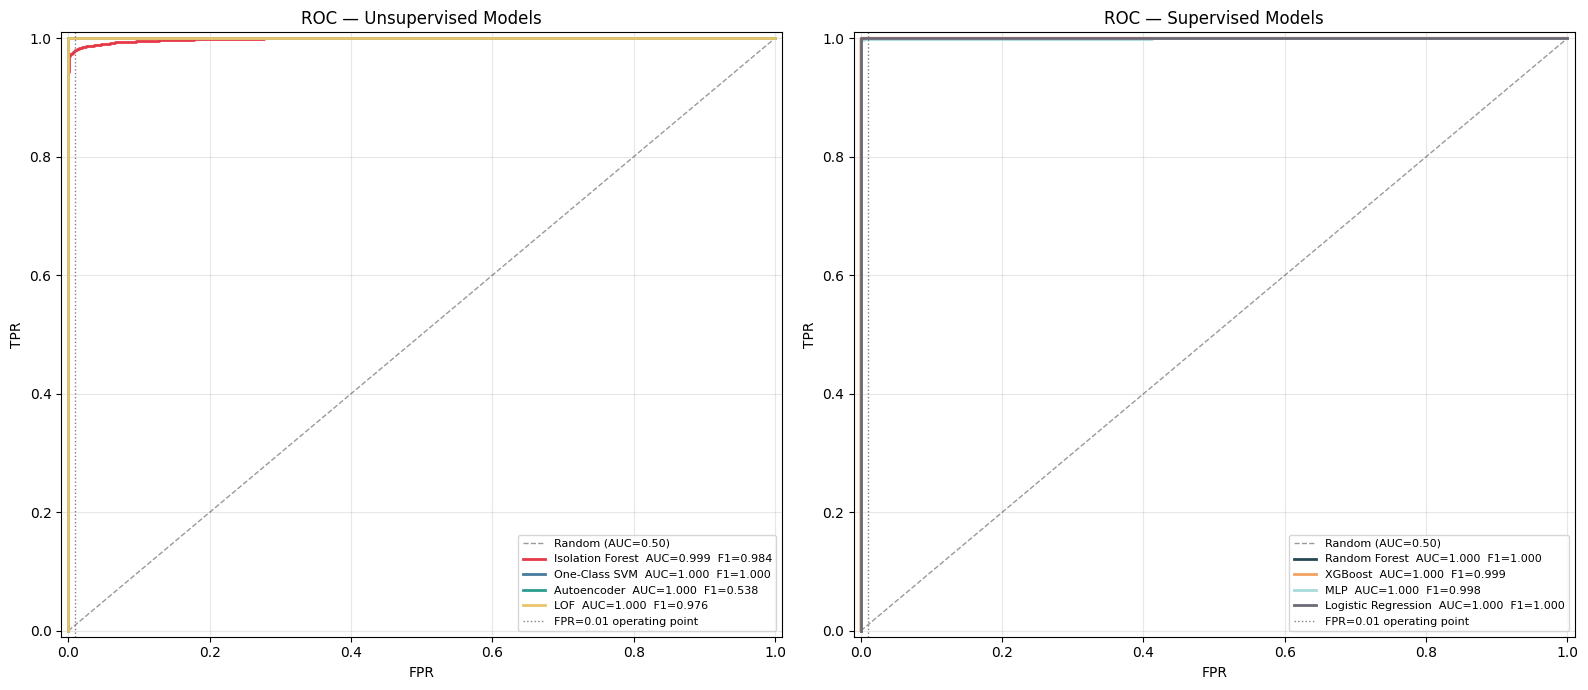

Saved: roc_curves.png


In [18]:
# 17. VISUALISATION A — ROC CURVES (unsup vs sup)

COLORS_U = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
COLORS_S = ['#264653', '#F4A261', '#A8DADC', '#6D6875']

unsup_names_ordered = [n for n in all_results if n in UNSUP_NAMES]
sup_names_ordered   = [n for n in all_results if n not in UNSUP_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (names, colors, title) in zip(
    axes,
    [
        (unsup_names_ordered, COLORS_U, 'Unsupervised Models'),
        (sup_names_ordered,   COLORS_S, 'Supervised Models'),
    ]
):
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random (AUC=0.50)')
    for i, name in enumerate(names):
        res = all_results[name]
        ax.plot(res['_fpr_arr'], res['_tpr_arr'],
                color=colors[i], lw=2,
                label=f"{name}  AUC={res['AUC-ROC']:.3f}  F1={res['F1 Score']:.3f}")
    ax.axvline(0.01, color='grey', ls=':', lw=1, label='FPR=0.01 operating point')
    ax.set(xlabel='FPR', ylabel='TPR', title=f'ROC — {title}',
           xlim=[-0.01,1.01], ylim=[-0.01,1.01])
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

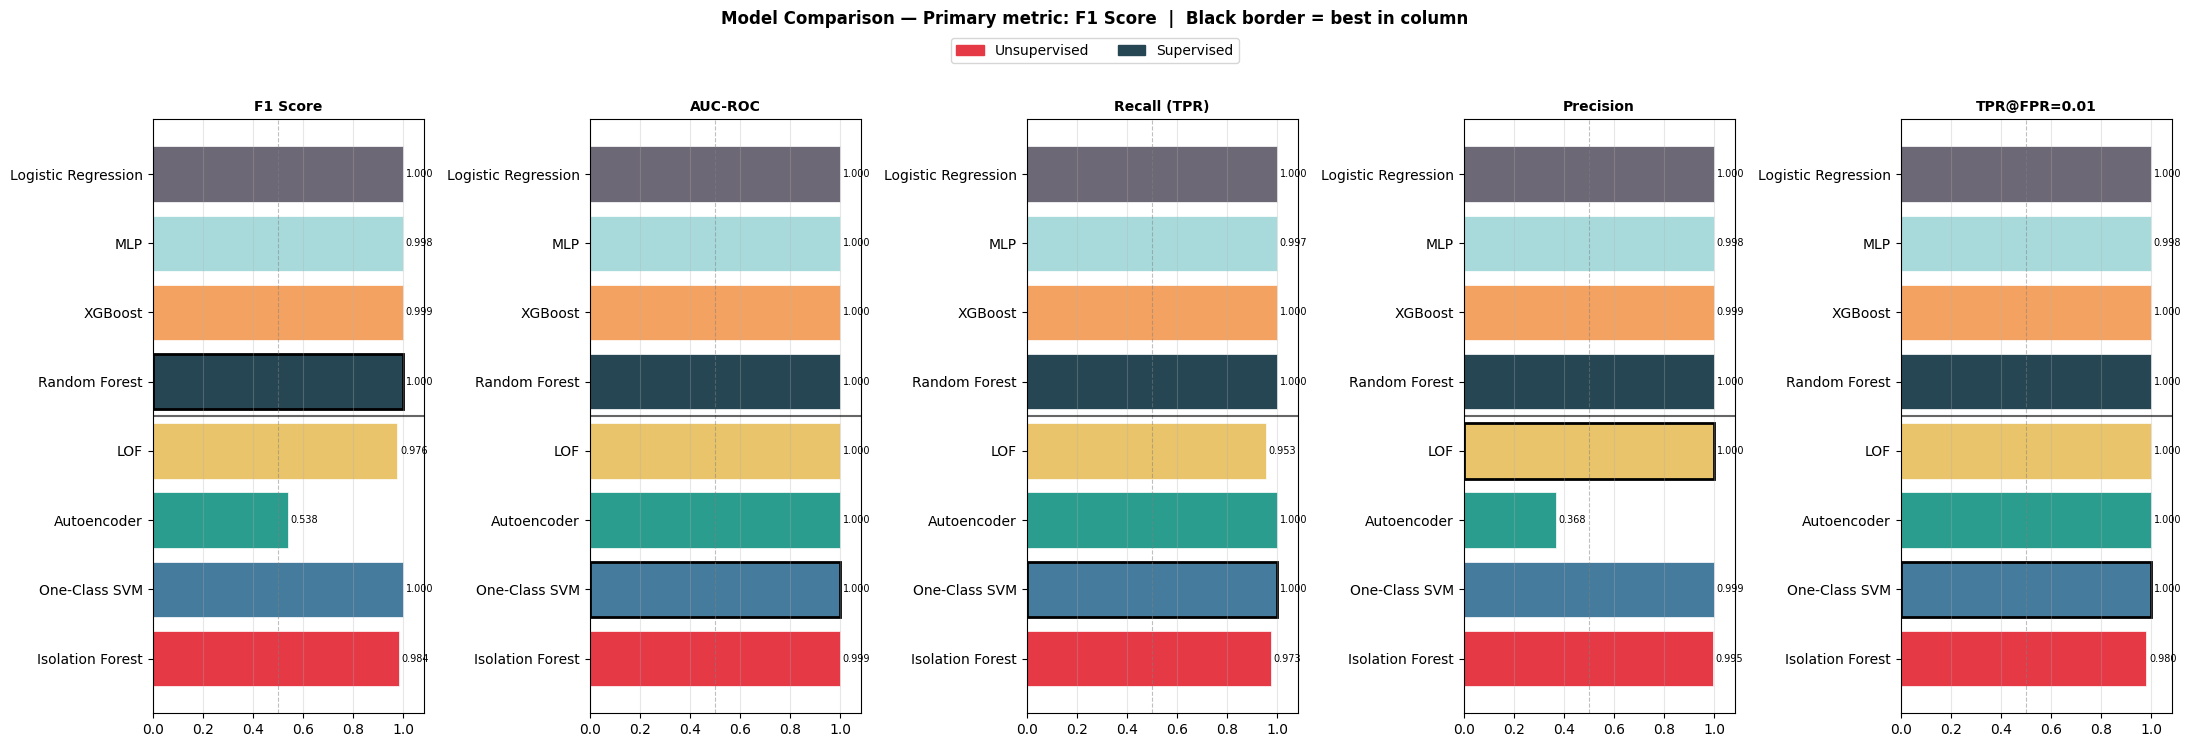

Saved: metric_comparison.png


In [19]:
# 18. VISUALISATION B — METRIC BAR CHART (F1 first)

metrics_to_plot = [
    'F1 Score', 'AUC-ROC', 'Recall (TPR)', 'Precision', 'TPR@FPR=0.01'
]
model_names = list(all_results.keys())
all_colors  = COLORS_U + COLORS_S

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 7))

for ax, metric in zip(axes, metrics_to_plot):
    vals = [all_results[m].get(metric, 0) for m in model_names]
    bars = ax.barh(model_names, vals, color=all_colors[:len(model_names)],
                   edgecolor='white', lw=0.5)
    # Mark best bar
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    ax.set_xlim(0, 1.08)
    ax.set_title(metric, fontweight='bold', fontsize=10)
    ax.axvline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
    # Separator unsup / sup
    ax.axhline(len(unsup_names_ordered) - 0.5,
               color='black', lw=1.5, alpha=0.6)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(min(val+0.01, 1.02), bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=7)

patch_u = mpatches.Patch(color=COLORS_U[0], label='Unsupervised')
patch_s = mpatches.Patch(color=COLORS_S[0], label='Supervised')
fig.legend(handles=[patch_u, patch_s], loc='upper center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.03))
plt.suptitle('Model Comparison — Primary metric: F1 Score  |  Black border = best in column',
             y=1.06, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_comparison.png')

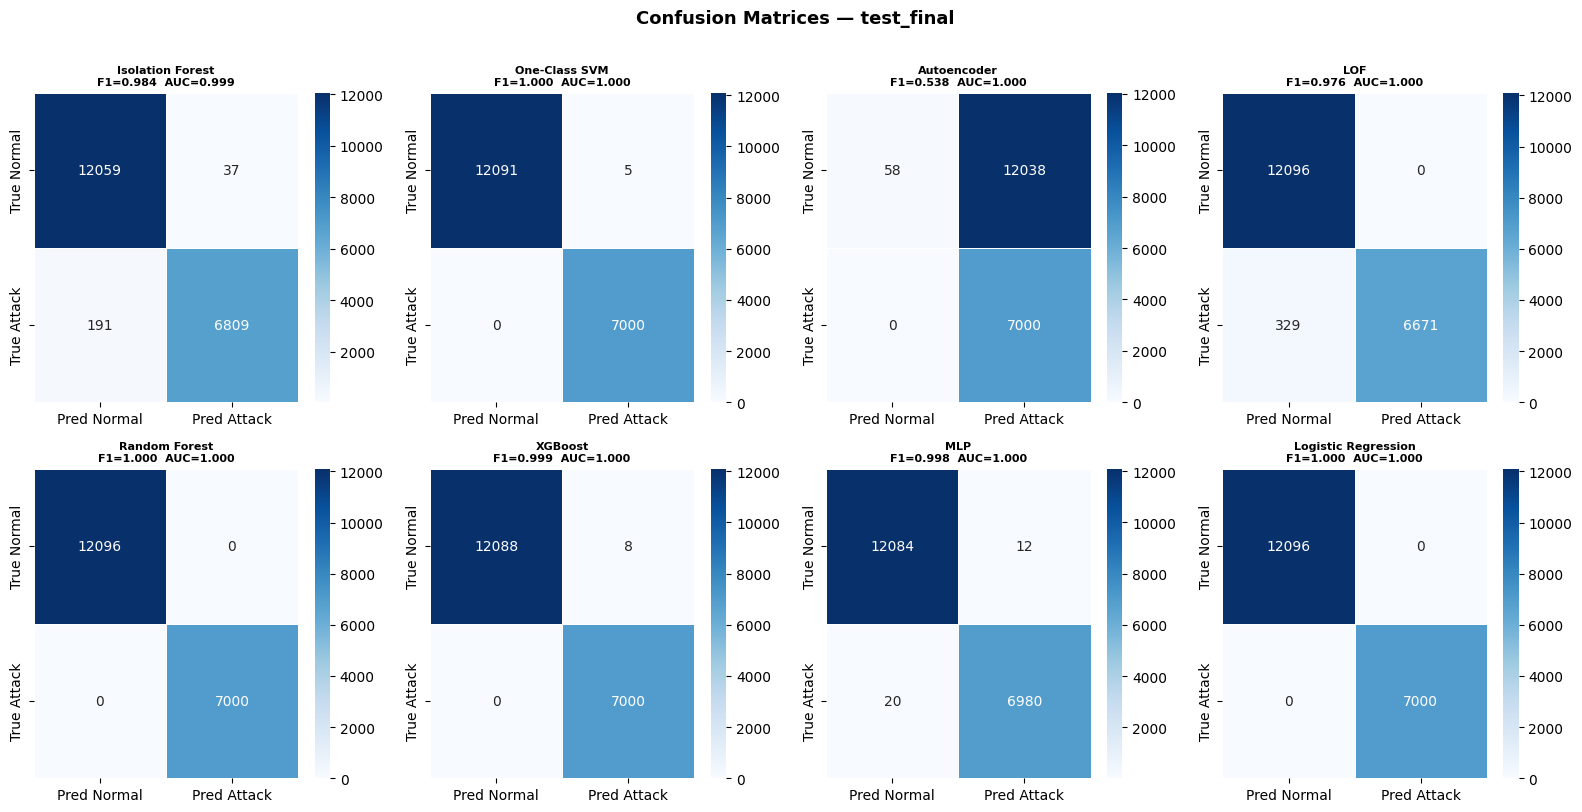

Saved: confusion_matrices.png


In [20]:
# 19. VISUALISATION C — CONFUSION MATRICES

n_models = len(all_results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
axes = axes.flatten()

for i, (name, res) in enumerate(all_results.items()):
    cm = np.array([[res['_TN'], res['_FP']],
                   [res['_FN'], res['_TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred Normal','Pred Attack'],
                yticklabels=['True Normal','True Attack'],
                linewidths=0.5, linecolor='white')
    axes[i].set_title(
        f'{name}\nF1={res["F1 Score"]:.3f}  AUC={res["AUC-ROC"]:.3f}',
        fontsize=8, fontweight='bold'
    )

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — test_final', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

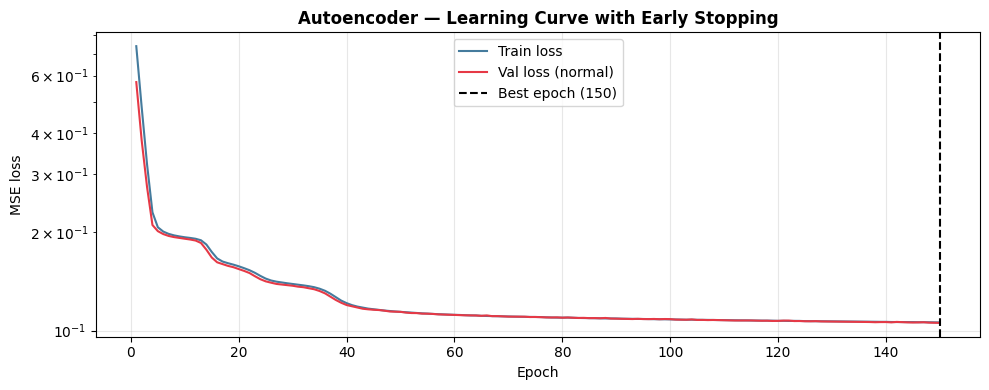

Saved: autoencoder_learning_curve.png


In [21]:
# 20. VISUALISATION D — AUTOENCODER LEARNING CURVE
#     Verifies early stopping behaviour

train_l = all_thresholds['Autoencoder']['train_losses']
val_l   = all_thresholds['Autoencoder']['val_losses']

fig, ax = plt.subplots(figsize=(10, 4))
epochs  = range(1, len(train_l)+1)
ax.plot(epochs, train_l, label='Train loss', color='#457B9D', lw=1.5)
ax.plot(epochs, val_l,   label='Val loss (normal)',  color='#E63946', lw=1.5)
best_ep = int(np.argmin(val_l)) + 1
ax.axvline(best_ep, color='black', ls='--', lw=1.5,
           label=f'Best epoch ({best_ep})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Autoencoder — Learning Curve with Early Stopping', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

if len(train_l) > 1:
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('autoencoder_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: autoencoder_learning_curve.png')

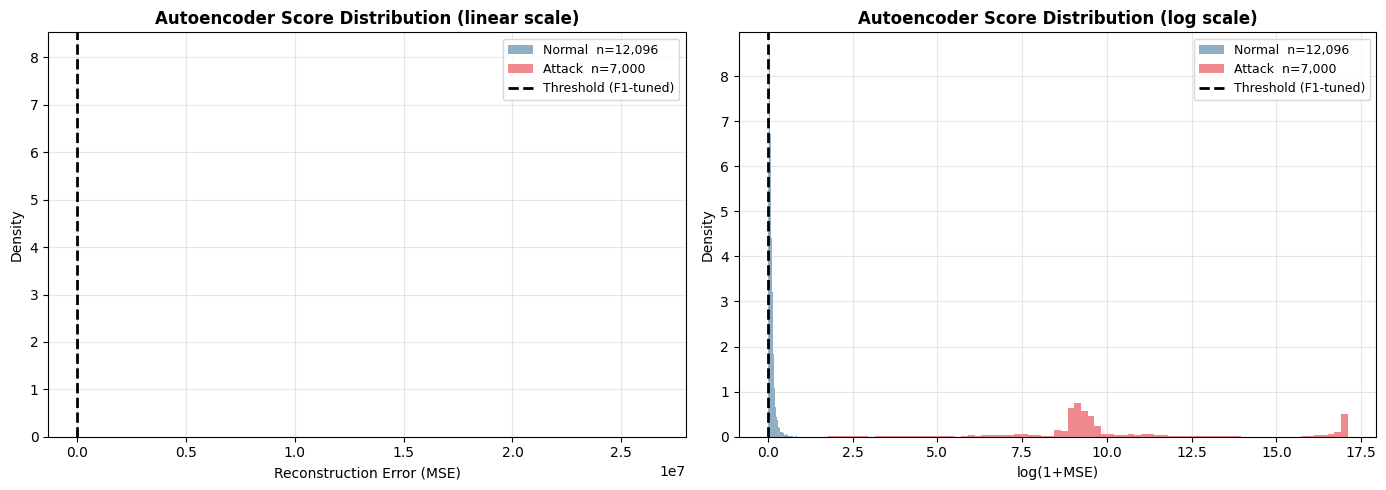

Saved: autoencoder_score_distribution.png


In [22]:
# 21. VISUALISATION E — ANOMALY SCORE DISTRIBUTION (Autoencoder)
#     Are normal and attack scores well-separated?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_scores = ae_scores_test[y_test_final == 0]
a_scores = ae_scores_test[y_test_final == 1]

for ax, scores_n, scores_a, scale, xlabel in [
    (ax1, n_scores, a_scores, 'linear', 'Reconstruction Error (MSE)'),
    (ax2, np.log1p(n_scores), np.log1p(a_scores), 'log', 'log(1+MSE)'),
]:
    ax.hist(scores_n, bins=80, alpha=0.6, color='#457B9D',
            label=f'Normal  n={len(scores_n):,}', density=True)
    ax.hist(scores_a, bins=80, alpha=0.6, color='#E63946',
            label=f'Attack  n={len(scores_a):,}', density=True)
    thr_disp = t_f1_ae if scale == 'linear' else np.log1p(t_f1_ae)
    ax.axvline(thr_disp, color='black', ls='--', lw=2,
               label=f'Threshold (F1-tuned)')
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.set_title(f'Autoencoder Score Distribution ({scale} scale)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('autoencoder_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: autoencoder_score_distribution.png')

In [23]:
# 22. VISUALISATION F — pct99 vs F1-tuned threshold comparison
#     Shows the improvement from data-driven threshold selection

thresh_rows = []
for name in unsup_names_ordered:
    th = all_thresholds[name]
    scores_v = {
        'Isolation Forest': scores_iso_val,
        'One-Class SVM'   : scores_ocsvm_val,
        'Autoencoder'     : ae_scores_val,
        'LOF'             : scores_lof_val,
    }[name]
    scores_t = {
        'Isolation Forest': scores_iso_test,
        'One-Class SVM'   : scores_ocsvm_test,
        'Autoencoder'     : ae_scores_test,
        'LOF'             : scores_lof_test,
    }[name]

    for method, thr in [('pct99', th['pct99']), ('f1_tuned', th['f1_tuned'])]:
        preds = (scores_t > thr).astype(int)
        thresh_rows.append({
            'Model': name, 'Method': method,
            'F1'  : round(f1_score(y_test_final, preds, zero_division=0), 4),
            'Rec' : round(recall_score(y_test_final, preds, zero_division=0), 4),
            'Prec': round(precision_score(y_test_final, preds, zero_division=0), 4),
        })

df_thresh = pd.DataFrame(thresh_rows)
print('=== Threshold method comparison (unsupervised models) ===')
print(df_thresh.to_string(index=False))
print('\nConclusion: F1-tuned threshold consistently improves F1 vs 99th-percentile heuristic.')

=== Threshold method comparison (unsupervised models) ===
           Model   Method     F1    Rec   Prec
Isolation Forest    pct99 0.9819 0.9784 0.9853
Isolation Forest f1_tuned 0.9835 0.9727 0.9946
   One-Class SVM    pct99 0.9907 1.0000 0.9816
   One-Class SVM f1_tuned 0.9996 1.0000 0.9993
     Autoencoder    pct99 0.9914 1.0000 0.9830
     Autoencoder f1_tuned 0.5377 1.0000 0.3677
             LOF    pct99 0.9911 1.0000 0.9823
             LOF f1_tuned 0.9759 0.9530 1.0000

Conclusion: F1-tuned threshold consistently improves F1 vs 99th-percentile heuristic.


---
## Discussion — Should we prefer Unsupervised or Supervised?

### When supervised models win on paper…
Supervised models (RF, XGBoost, MLP) are trained on **labelled attack windows** from the same synthetic dataset distribution. If the test attacks are drawn from the same distribution, supervised models will generally achieve higher F1 and AUC.

### …but anomaly detection is more appropriate for this project

| Criterion | Unsupervised (Anomaly Detection) | Supervised |
|---|---|---|
| **Novel attack types** |  Detects zero-day variants — model knows only what *normal* looks like |  Only detects attack patterns seen in training |
| **Label availability** |  Needs only normal traffic — abundant in any real network |  Needs labelled attack data — hard to obtain in production |
| **Federated learning fit** |  Each FL client trains on its own normal traffic; no attack data needed across clients |  Attack labels would need to be shared across clients |
| **Distribution shift** |  Robust: learns the *shape* of normal |  Brittle: new attack style → retrain |
| **Interpretability** |  Reconstruction error has a clear meaning |  Black-box for deep models |

### Why the supervised numbers may be optimistic
The supervised models were trained on **`val_labeled`**, which comes from the **same synthetic generator** as `test_final`.  
In a real deployment, new DDoS campaigns will use **different parameters** than anything in the synthetic dataset.  
An autoencoder trained only on normal traffic is immune to this problem.

- **For the federated learning system**: it's better use the **Autoencoder** (or Isolation Forest as a lighter alternative).  
  - Fits the FL paradigm (train locally on normal traffic, share encoder weights).
  - Generalises to unseen attacks.
  - Threshold is tunable post-deployment without retraining..



In [24]:
# 23. FINAL SUMMARY TABLE (formatted for the report)

hdr = (f'{"Model":<22} {"Type":<8} {"F1":>7} {"AUC-ROC":>9} '
       f'{"Recall":>8} {"Prec":>8} {"FPR":>7} {"TPR@1%":>8} {"TPR@5%":>8}')
sep = '-' * len(hdr)

print('='*len(hdr))
print('FINAL RESULTS  —  test_final  —  ranked by F1')
print('='*len(hdr))
print(hdr)
print(sep)

for name in rank.index:
    res   = all_results[name]
    mtype = 'Unsup.' if name in UNSUP_NAMES else 'Sup.'
    print(f'{name:<22} {mtype:<8} '
          f'{res["F1 Score"]:>7.4f} {res["AUC-ROC"]:>9.4f} '
          f'{res["Recall (TPR)"]:>8.4f} {res["Precision"]:>8.4f} '
          f'{res["FPR"]:>7.4f} {res["TPR@FPR=0.01"]:>8.4f} '
          f'{res["TPR@FPR=0.05"]:>8.4f}')
    if name == unsup_names_ordered[-1]:
        print(sep )

print('='*len(hdr))
print(f'\nBest overall  (F1): {winner} — F1={winner_f1:.4f}')
print(f'Best unsup.   (F1): {best_unsup} — F1={rank.loc[best_unsup,"F1 Score"]:.4f}')
print(f'Best sup.     (F1): {best_sup} — F1={rank.loc[best_sup,"F1 Score"]:.4f}')
print()


FINAL RESULTS  —  test_final  —  ranked by F1
Model                  Type          F1   AUC-ROC   Recall     Prec     FPR   TPR@1%   TPR@5%
---------------------------------------------------------------------------------------------
Logistic Regression    Sup.      1.0000    1.0000   1.0000   1.0000  0.0000   1.0000   1.0000
Random Forest          Sup.      1.0000    1.0000   1.0000   1.0000  0.0000   1.0000   1.0000
One-Class SVM          Unsup.    0.9996    1.0000   1.0000   0.9993  0.0004   1.0000   1.0000
XGBoost                Sup.      0.9994    1.0000   1.0000   0.9989  0.0007   1.0000   1.0000
MLP                    Sup.      0.9977    0.9996   0.9971   0.9983  0.0010   0.9983   0.9989
Isolation Forest       Unsup.    0.9835    0.9985   0.9727   0.9946  0.0031   0.9797   0.9900
LOF                    Unsup.    0.9759    1.0000   0.9530   1.0000  0.0000   1.0000   1.0000
---------------------------------------------------------------------------------------------
Autoencoder   